# Used Car Listings — SQL Analysis (Phase 2)

Phase 1 answered these questions with pandas on a CSV. This phase rebuilds them as SQL against a real database, and asks a couple of questions pandas alone made awkward: JOINs across tables and ranking within groups.

**Setup:** the phase 1 cleaned data now lives in `data/processed/used_cars.db`, a SQLite database with two tables — `listings` (the cleaned car data) and `regions` (a lookup mapping each state to a US Census region, built so region-level questions can be a real JOIN instead of a manual dictionary). Schema in `sql/schema.sql`, every query below also lives standalone in `sql/queries.sql`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

conn = sqlite3.connect('../data/processed/used_cars.db')

## 1. Why a database instead of just the CSV?

A single flat file can't represent "each state belongs to one region" without repeating the region name on every row. Splitting that into its own `regions` table — one row per state — means the mapping is stored once, and any query that needs it just joins to get it. That's the core idea behind normalizing a schema instead of keeping everything in one wide table.

In [2]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

for t in tables['name']:
    n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn)['n'][0]
    print(f"{t}: {n} rows")

       name
0  listings
1   regions
listings: 2448 rows
regions: 52 rows


## 2. The basics

In [3]:
query = '''
SELECT COUNT(*) AS total_listings,
       MIN(price) AS min_price,
       MAX(price) AS max_price,
       ROUND(AVG(price), 0) AS avg_price
FROM listings;
'''
pd.read_sql_query(query, conn)

,total_listings,min_price,max_price,avg_price
0,2448,25,84900,19123.0


## 3. Which brands show up most, and what do they go for?

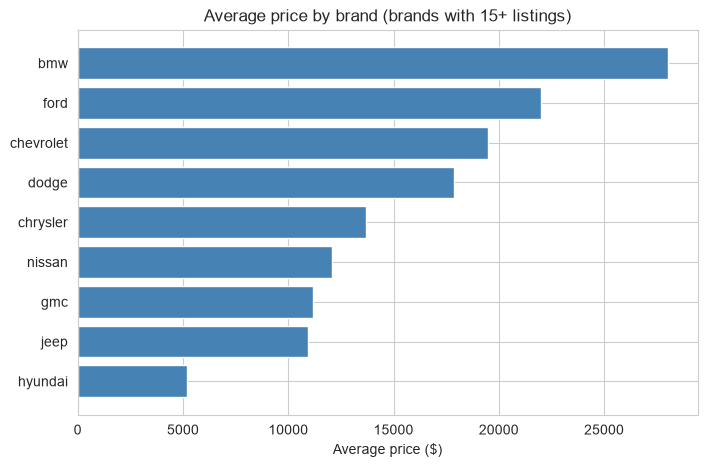

,brand,n,avg_price
0,bmw,16,28047.0
1,ford,1216,22003.0
2,chevrolet,283,19498.0
3,dodge,430,17865.0
4,chrysler,18,13686.0
5,nissan,312,12066.0
6,gmc,40,11190.0
7,jeep,30,10934.0
8,hyundai,15,5203.0


In [4]:
query = '''
SELECT brand, COUNT(*) AS n, ROUND(AVG(price), 0) AS avg_price
FROM listings
GROUP BY brand
HAVING n >= 15
ORDER BY avg_price DESC;
'''
brand_df = pd.read_sql_query(query, conn)

fig, ax = plt.subplots()
ax.barh(brand_df['brand'], brand_df['avg_price'], color='steelblue')
ax.set_xlabel('Average price ($)')
ax.set_title('Average price by brand (brands with 15+ listings)')
ax.invert_yaxis()
plt.show()

brand_df

Same ranking pandas found in phase 1 — BMW highest, Jeep and GMC lowest among brands with real sample sizes. Good sign: two different tools, same answer.

## 4. Clean title vs. salvage insurance, confirmed in SQL

In [5]:
query = '''
SELECT title_status, COUNT(*) AS n,
       ROUND(AVG(price), 0) AS avg_price,
       MIN(price) AS min_price, MAX(price) AS max_price
FROM listings
GROUP BY title_status;
'''
pd.read_sql_query(query, conn)

,title_status,n,avg_price,min_price,max_price
0,clean vehicle,2331,19921.0,720,84900
1,salvage insurance,117,3236.0,25,20000


Matches phase 1: salvage-insurance listings average roughly $3,200 against roughly $19,900 for clean titles — still the largest single price gap in the dataset.

## 5. Does region of the country matter?

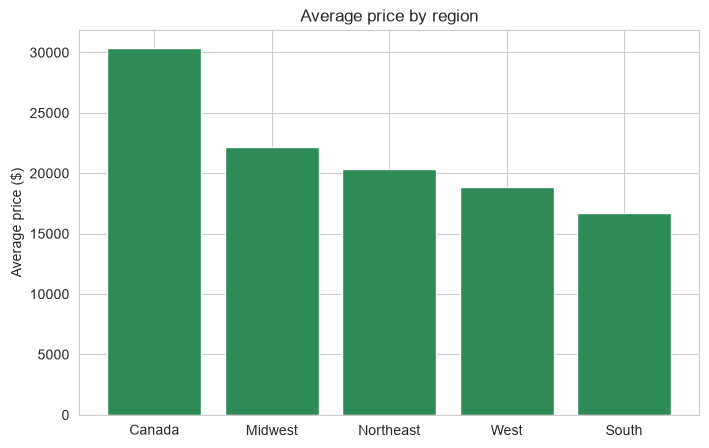

,region,n,avg_price
0,Canada,7,30357.0
1,Midwest,582,22190.0
2,Northeast,503,20334.0
3,West,374,18888.0
4,South,982,16696.0


In [6]:
query = '''
SELECT r.region, COUNT(*) AS n, ROUND(AVG(l.price), 0) AS avg_price
FROM listings l
JOIN regions r ON l.state = r.state
GROUP BY r.region
ORDER BY avg_price DESC;
'''
region_df = pd.read_sql_query(query, conn)

fig, ax = plt.subplots()
ax.bar(region_df['region'], region_df['avg_price'], color='seagreen')
ax.set_ylabel('Average price ($)')
ax.set_title('Average price by region')
plt.show()

region_df

This is new — phase 1 never looked at geography. Taken at face value, the Midwest and Northeast run higher than the South, and Canada looks highest of all on only 7 listings — far too few to mean anything.

But a raw `AVG(price)` per region is a *weak* piece of evidence, for two reasons this query can't see:

1. **It controls for nothing.** If Southern listings happen to carry more mileage, or more salvage titles, the region column gets credit for an effect that belongs to mileage or title status.
2. **"Region" may not be a real unit.** Some of these regions are dominated by a single state, so a "regional" average can be one state's local market wearing a region's name.

Both are testable, so the next section tests them rather than taking the ranking at face value.

## 5b. Does the region effect survive controls?

Three checks: hold mileage/year/title/brand constant, cluster the standard errors by state (listings in one state aren't independent draws — same local market, often the same auction), and drop each region's largest state to see whether the effect was ever regional to begin with.

In [7]:
import numpy as np
import statsmodels.formula.api as smf

# Pull the columns needed to control for the obvious alternative explanations.
reg_df = pd.read_sql_query("""
    SELECT l.price, l.mileage, l.year, l.title_status, l.brand, l.state, r.region
    FROM listings l JOIN regions r ON l.state = r.state
""", conn)

# Drop Canada: 7 listings can't support a regional claim either way.
us = reg_df[reg_df.region != 'Canada'].copy()
# South is the baseline (largest group), so each coefficient reads as
# "dollars above the South".
us['region'] = pd.Categorical(us.region, categories=['South', 'West', 'Northeast', 'Midwest'])

FORMULA = 'price ~ C(region) + mileage + year + C(title_status) + C(brand)'

naive     = smf.ols('price ~ C(region)', data=us).fit()
controlled = smf.ols(FORMULA, data=us).fit()
clustered  = smf.ols(FORMULA, data=us).fit(cov_type='cluster',
                                           cov_kwds={'groups': us.state})

print(f"region alone explains R2 = {naive.rsquared:.3f} of price variation")
print(f"with controls,           R2 = {controlled.rsquared:.3f}\n")
print(f"{'region vs South':<18}{'raw':>9}{'controlled':>12}{'p (clustered)':>15}")
for r in ['West', 'Northeast', 'Midwest']:
    k = f'C(region)[T.{r}]'
    print(f"{r:<18}{naive.params[k]:>+9,.0f}{controlled.params[k]:>+12,.0f}"
          f"{clustered.pvalues[k]:>15.3f}")

# Leave-one-state-out: if a "region" effect is really one state, removing that
# state should make it vanish.
print("\ndrop each region's largest state, refit:")
for r in ['West', 'Northeast', 'Midwest']:
    biggest = us[us.region == r].state.value_counts().index[0]
    sub = us[us.state != biggest].copy()
    sub['region'] = pd.Categorical(sub.region,
                                   categories=['South', 'West', 'Northeast', 'Midwest'])
    fit = smf.ols(FORMULA, data=sub).fit()
    k = f'C(region)[T.{r}]'
    share = (us[us.region == r].state == biggest).mean() * 100
    print(f"  {r:<10} without {biggest:<13} ({share:.0f}% of region): "
          f"{fit.params[k]:>+8,.0f}  (was {controlled.params[k]:>+8,.0f})  p={fit.pvalues[k]:.3f}")

# Why the raw gap shrinks: the South simply carries more miles.
print("\nmean mileage by region (the main confounder):")
print(us.groupby('region', observed=True).mileage.mean().round(0).to_string())

region alone explains R2 = 0.035 of price variation
with controls,           R2 = 0.373

region vs South         raw  controlled  p (clustered)
West                 +2,192      +1,023          0.301
Northeast            +3,638      +1,785          0.163
Midwest              +5,494      +4,054          0.002

drop each region's largest state, refit:
  West       without california    (49% of region):   +1,602  (was   +1,023)  p=0.036
  Northeast  without pennsylvania  (59% of region):      +76  (was   +1,785)  p=0.918
  Midwest    without michigan      (29% of region):   +4,237  (was   +4,054)  p=0.000

mean mileage by region (the main confounder):
region
South        56228.0
West         45975.0
Northeast    45131.0
Midwest      41834.0


**The Midwest result holds. The Northeast result does not.**

- **Midwest: +$4,054 over the South** after controlling for mileage, year, title status and brand — down from a raw +$5,494, so about a quarter of the raw gap was confounding. It stays significant with state-clustered standard errors (p≈0.002) and *survives dropping Michigan*, its largest state. This is a real finding.
- **Northeast: collapses from +$1,785 to +$76 (p≈0.92)** once Pennsylvania is removed — and Pennsylvania is 59% of the region's listings. There is no Northeast effect; there is a Pennsylvania effect that a region label was hiding. It was already insignificant under clustered standard errors before dropping anything.
- **West** is not significant either way and moves unpredictably when California is dropped. No claim.

**The main confounder was mileage, not salvage title.** Southern listings average ~56,200 miles against the Midwest's ~41,800 — a 14,400-mile gap, worth roughly $1,200 at the model's fitted rate per mile. Controlling for title status alone barely moved the regional gap at all, because the salvage share only differs by a few points between regions.

**The honest size of this effect:** region alone explains about **3.5% of price variation**, and the spread *within* regions is larger than the gap between them — Illinois averages ~$28,900 against Missouri's ~$16,000 inside the Midwest, while Oklahoma (~$24,000) beats every Midwest state but two from inside the "cheap" South. Region is a leaky abstraction over what are really state-level markets.

One caveat no amount of controlling fixes: this is **auction** data, so a regional gap may reflect which inventory moves through which auction houses rather than consumer geography. This dataset can't separate those.

In [8]:
query = '''
SELECT brand, title_status, ROUND(AVG(price), 0) AS avg_price,
       RANK() OVER (PARTITION BY title_status ORDER BY AVG(price) DESC) AS price_rank
FROM listings
GROUP BY brand, title_status
HAVING COUNT(*) >= 10
ORDER BY title_status, price_rank;
'''
pd.read_sql_query(query, conn)

,brand,title_status,avg_price,price_rank
0,bmw,clean vehicle,31714.0,1
1,mercedes-benz,clean vehicle,28704.0,2
2,ford,clean vehicle,22846.0,3
3,buick,clean vehicle,21359.0,4
4,chevrolet,clean vehicle,20408.0,5
5,dodge,clean vehicle,18429.0,6
6,chrysler,clean vehicle,15384.0,7
7,infiniti,clean vehicle,13098.0,8
8,nissan,clean vehicle,12741.0,9
9,gmc,clean vehicle,12056.0,10


Chevrolet is the clearest mover: solidly mid-pack among clean titles but the cheapest of the four major brands once salvaged, while Ford holds its relative position in both groups. That's a brand-by-title_status interaction phase 1's brand-only chart couldn't show.

## 7. Which brands sell above the overall average?

In [9]:
query = '''
SELECT brand, ROUND(AVG(price), 0) AS avg_price
FROM listings
GROUP BY brand
HAVING avg_price > (SELECT AVG(price) FROM listings)
ORDER BY avg_price DESC;
'''
pd.read_sql_query(query, conn)

,brand,avg_price
0,lincoln,36300.0
1,lexus,33220.0
2,maserati,30300.0
3,land,28900.0
4,mercedes-benz,28704.0
5,bmw,28047.0
6,cadillac,27712.0
7,ford,22003.0
8,buick,21359.0
9,chevrolet,19498.0


The subquery in `HAVING` recomputes the overall average on the fly, so this stays correct even if the underlying data changes — no hardcoded number to go stale. Mostly luxury nameplates above the line, plus Ford, Buick, and Chevrolet as the non-luxury brands that still clear it.

## 8. From here to an actual dashboard

Everything above is a query I can run and a chart I can draw here — but a Power BI / Tableau dashboard needs its own desktop app, so that part happens on your end, not mine. Here's the concrete spec, straight from what these queries turned up:

**Connect the dashboard tool to `used_cars.db`** (or export `listings`/`regions` to CSV if the tool you're using can't read SQLite directly).

Build four visuals:
1. **KPI cards** — total listings, average price, median price (top of the dashboard)
2. **Bar chart** — average price by brand, filterable by title status
3. **Bar chart** — average price by region
4. **Scatter plot** — price vs. mileage, colored by title status (this is the one visual none of the SQL above produces, and it's the clearest single picture of what actually drives price)

Add one filter/slicer: **title status** (clean vehicle / salvage insurance), so the whole dashboard can toggle between "all listings" and "clean titles only" — the salvage group is skewing several of these averages down, and a real dashboard user would want to see both views.

## Key takeaways

- The two-table schema (`listings` + `regions`) isn't just structure for its own sake — it's what makes the region question answerable as a JOIN instead of a manual lookup.
- Every phase 1 finding held up in SQL: title status is still the biggest price driver, brand ranking is unchanged.
- Region is a genuinely new finding this phase surfaced, but only half of it survived testing: the **Midwest** premium over the South holds up under controls, clustered standard errors, and dropping its largest state (+$4,054), while the apparent **Northeast** premium turned out to be Pennsylvania alone (+$76, p=0.92 once PA is excluded). The Canada figure is untrustworthy at n=7.
- A raw `GROUP BY` average is a starting point, not a finding. Region explains only ~3.5% of price variation, and within-region spread exceeds the between-region gap — the checks in 5b are what separate the one real result from the two spurious ones.
- The window function surfaced something aggregation alone couldn't: brands don't hold their relative price rank the same way across title status — Chevrolet drops the furthest.
- Next: build the four-visual dashboard described above in Power BI or Tableau Public, then phase 3 — a price-prediction model combining mileage, year, title status, and brand.